# 02 — Probability Foundations
**References:** Kolmogorov (1933) · Bayes (1763) · Ross (2010) *A First Course in Probability*

## Narrative thread
```
Axioms -> Conditional probability -> Independence -> Bayes theorem -> Common mistakes
```

## Kolmogorov axioms

Let $\Omega$ be a sample space and $\mathcal{F}$ a $\sigma$-algebra of events. A **probability measure** $P$ satisfies:

1. $P(A) \geq 0$ for all $A \in \mathcal{F}$
2. $P(\Omega) = 1$
3. For disjoint events $A_1, A_2, \ldots$: $P\left(\bigcup_i A_i\right) = \sum_i P(A_i)$

All probability rules follow from these three axioms.

| Rule | Formula |
|---|---|
| Complement | $P(A^c) = 1 - P(A)$ |
| Addition | $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ |
| Conditional | $P(A \mid B) = P(A \cap B) / P(B)$ |
| Multiplication | $P(A \cap B) = P(A \mid B)\,P(B)$ |
| Total probability | $P(A) = \sum_i P(A \mid B_i)\,P(B_i)$ |

## Independence

$A$ and $B$ are **independent** iff $P(A \cap B) = P(A)\,P(B)$, equivalently $P(A \mid B) = P(A)$.

**Caution:** independence $\neq$ mutually exclusive. Two disjoint events (both can't happen)
are *negatively* dependent — knowing one occurred tells you the other didn't.

## Bayes theorem

$$P(H \mid D) = \frac{P(D \mid H)\,P(H)}{P(D)} = \frac{P(D \mid H)\,P(H)}{P(D \mid H)\,P(H) + P(D \mid H^c)\,P(H^c)}$$

| Term | Name | Meaning |
|---|---|---|
| $P(H)$ | Prior | Belief before seeing data |
| $P(D \mid H)$ | Likelihood | How probable is the data if $H$ is true |
| $P(H \mid D)$ | Posterior | Updated belief after seeing data |
| $P(D)$ | Marginal likelihood | Normalizing constant |

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

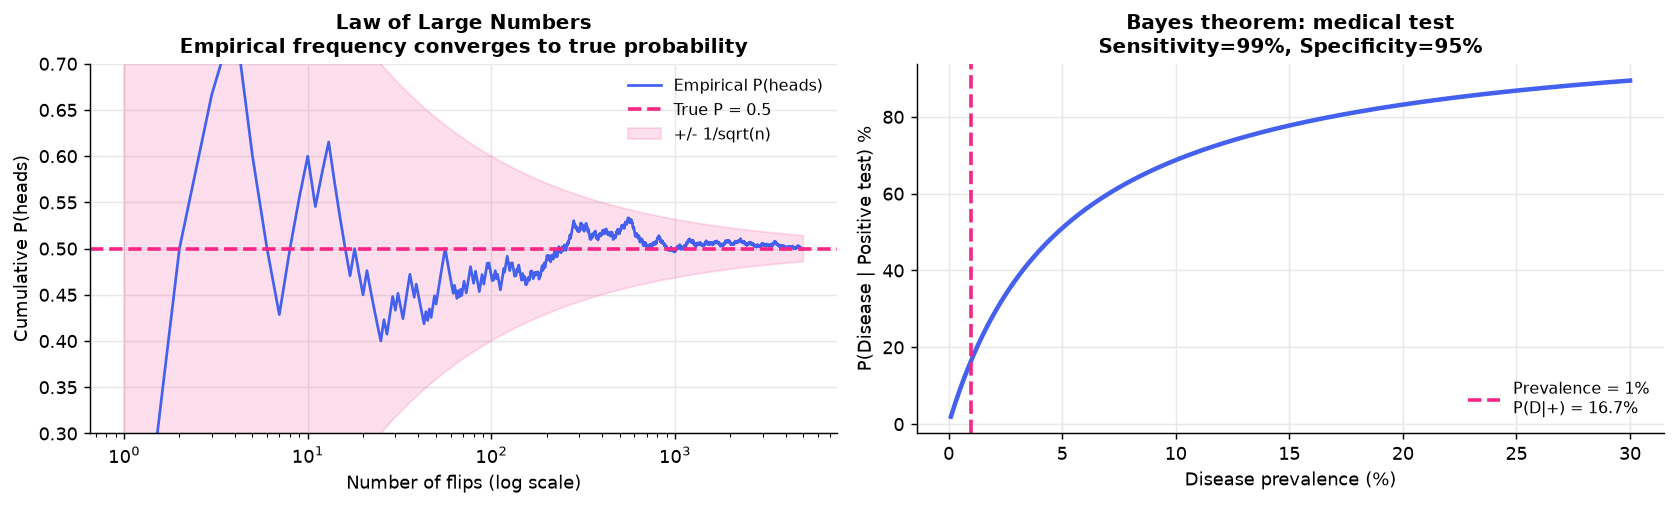

Medical test example (prevalence=1%):
  P(Test positive)        = 0.0594
  P(Disease | Test +)     = 0.1667  <- only 16.7%!
  P(No disease | Test +)  = 0.8333

Interpretation: even with a 99% accurate test, a positive result
on a rare disease (1% prevalence) is wrong 84% of the time.
This is the base rate fallacy.


In [2]:
# ── Simulation: Law of Large Numbers ─────────────────────────────────────
# P(heads) = 0.5; watch empirical frequency converge

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ns = np.arange(1, 5001)
flips = np.random.binomial(1, 0.5, 5000)
cum_mean = np.cumsum(flips) / ns

ax = axes[0]
ax.plot(ns, cum_mean, color='#4361ee', lw=1.5, label='Empirical P(heads)')
ax.axhline(0.5, color='#f72585', lw=2, linestyle='--', label='True P = 0.5')
ax.fill_between(ns, 0.5 - 1/np.sqrt(ns), 0.5 + 1/np.sqrt(ns),
                alpha=0.15, color='#f72585', label='+/- 1/sqrt(n)')
ax.set_xscale('log'); ax.set_ylim(0.3, 0.7)
ax.set_xlabel('Number of flips (log scale)'); ax.set_ylabel('Cumulative P(heads)')
ax.set_title('Law of Large Numbers\nEmpirical frequency converges to true probability')
ax.legend(fontsize=9)

# ── Bayes theorem: medical test example ─────────────────────────────────
# Disease prevalence 1%; test sensitivity 99%; specificity 95%
p_disease    = 0.01    # P(D)
sensitivity  = 0.99    # P(Test+ | D)
specificity  = 0.95    # P(Test- | no D) -> false positive rate = 0.05

p_no_disease = 1 - p_disease
fp_rate      = 1 - specificity

p_test_pos = sensitivity * p_disease + fp_rate * p_no_disease  # total probability
p_disease_given_pos = (sensitivity * p_disease) / p_test_pos   # Bayes

ax2 = axes[1]
# Show how posterior changes with prevalence
prevalences = np.linspace(0.001, 0.3, 300)
posteriors  = (sensitivity * prevalences) / (sensitivity * prevalences + fp_rate * (1-prevalences))
ax2.plot(prevalences * 100, posteriors * 100, color='#4361ee', lw=2.5)
ax2.axvline(p_disease * 100, color='#f72585', lw=2, linestyle='--',
            label=f'Prevalence = {p_disease*100:.0f}%\nP(D|+) = {p_disease_given_pos*100:.1f}%')
ax2.set_xlabel('Disease prevalence (%)'); ax2.set_ylabel('P(Disease | Positive test) %')
ax2.set_title(f'Bayes theorem: medical test\nSensitivity={sensitivity:.0%}, Specificity={specificity:.0%}')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Medical test example (prevalence={p_disease:.0%}):')
print(f'  P(Test positive)        = {p_test_pos:.4f}')
print(f'  P(Disease | Test +)     = {p_disease_given_pos:.4f}  <- only {p_disease_given_pos:.1%}!')
print(f'  P(No disease | Test +)  = {1-p_disease_given_pos:.4f}')
print()
print('Interpretation: even with a 99% accurate test, a positive result')
print('on a rare disease (1% prevalence) is wrong 84% of the time.')
print('This is the base rate fallacy.')

## Common probability mistakes

| Mistake | Description | Correct reasoning |
|---|---|---|
| **Base rate fallacy** | Ignoring $P(H)$ in Bayes theorem | Always multiply likelihood by prior |
| **Gambler's fallacy** | "I've had 5 heads, next must be tails" | Independent events have no memory |
| **Prosecutor's fallacy** | Confusing $P(E \mid \text{innocent})$ with $P(\text{innocent} \mid E)$ | Transpose via Bayes |
| **Conjunction fallacy** | $P(A \cap B) > P(A)$ | Always: $P(A \cap B) \leq P(A)$ |
| **Simpson's paradox** | Aggregate trend reverses in subgroups | Always check for confounders |

## Expected value and variance

For a discrete random variable $X$ with PMF $p(x)$:
$$E[X] = \sum_x x\,p(x) \qquad \text{Var}(X) = E[X^2] - (E[X])^2$$

Key properties:
- $E[aX + b] = a\,E[X] + b$
- $\text{Var}(aX + b) = a^2\,\text{Var}(X)$
- If $X, Y$ independent: $\text{Var}(X + Y) = \text{Var}(X) + \text{Var}(Y)$

Simpson's Paradox — UC Berkeley admissions (1973)
  Overall admission rate: Men=46.0%  Women=30.4%  <- looks biased against women

  By department:
  Dept A: Men=62.1%  Women=82.4%  <- Women higher
  Dept B: Men=63.0%  Women=68.0%  <- Women higher
  Dept C: Men=36.9%  Women=34.1%  
  Dept D: Men=33.1%  Women=34.9%  <- Women higher
  Dept E: Men=27.7%  Women=23.9%  
  Dept F: Men=5.9%  Women=7.0%  <- Women higher

  Resolution: women applied more to competitive departments (C,E,F).
  The confounder is department selectivity.


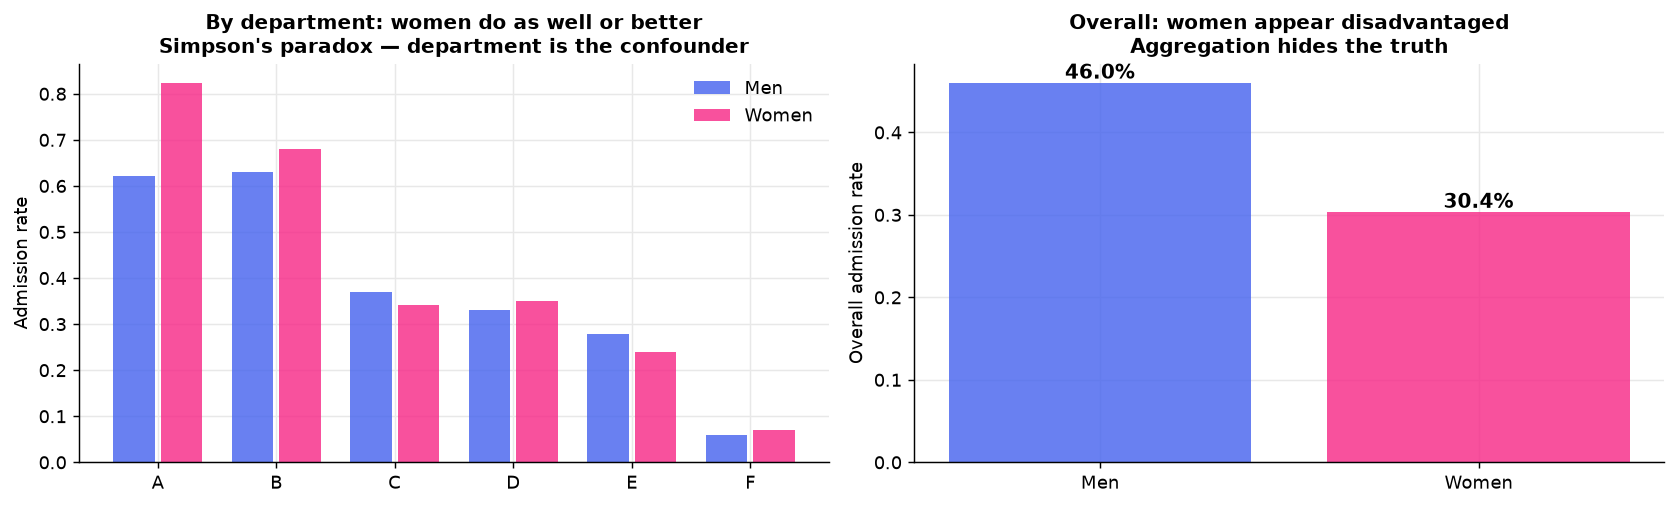

In [3]:
# ── Simpson's Paradox ────────────────────────────────────────────────────
# Admission rates by gender — UC Berkeley 1973 (Bickel et al., 1975)
np.random.seed(0)
data = {
    'Dept': ['A','A','B','B','C','C','D','D','E','E','F','F'],
    'Gender': ['M','F']*6,
    'Applied': [825,108, 560,25, 325,593, 417,375, 191,393, 272,341],
    'Admitted': [512,89,  353,17, 120,202, 138,131, 53,94,   16,24],
}
berk = pd.DataFrame(data)
berk['Rate'] = berk['Admitted'] / berk['Applied']

# Overall rate
total_m = berk[berk.Gender=='M'][['Applied','Admitted']].sum()
total_f = berk[berk.Gender=='F'][['Applied','Admitted']].sum()
overall_m = total_m['Admitted'] / total_m['Applied']
overall_f = total_f['Admitted'] / total_f['Applied']

print("Simpson's Paradox — UC Berkeley admissions (1973)")
print(f'  Overall admission rate: Men={overall_m:.1%}  Women={overall_f:.1%}  <- looks biased against women')
print()
print('  By department:')
for dept in ['A','B','C','D','E','F']:
    sub = berk[berk.Dept==dept]
    rm = sub[sub.Gender=='M']['Rate'].values[0]
    rf = sub[sub.Gender=='F']['Rate'].values[0]
    print(f'  Dept {dept}: Men={rm:.1%}  Women={rf:.1%}  {"<- Women higher" if rf>rm else ""}')
print()
print('  Resolution: women applied more to competitive departments (C,E,F).')
print('  The confounder is department selectivity.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(6)
rm = berk[berk.Gender=='M']['Rate'].values
rf = berk[berk.Gender=='F']['Rate'].values
axes[0].bar(x-0.2, rm, 0.35, color='#4361ee', alpha=0.8, label='Men')
axes[0].bar(x+0.2, rf, 0.35, color='#f72585', alpha=0.8, label='Women')
axes[0].set_xticks(x); axes[0].set_xticklabels(['A','B','C','D','E','F'])
axes[0].set_ylabel('Admission rate'); axes[0].legend()
axes[0].set_title("By department: women do as well or better\nSimpson's paradox — department is the confounder")

axes[1].bar(['Men','Women'], [overall_m, overall_f], color=['#4361ee','#f72585'], alpha=0.8)
axes[1].set_ylabel('Overall admission rate')
axes[1].set_title("Overall: women appear disadvantaged\nAggregation hides the truth")
for i, v in enumerate([overall_m, overall_f]):
    axes[1].text(i, v+0.005, f'{v:.1%}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()